# Exoplanet Transit Detection using Kepler Data

This project analyzes archival data to detect an exoplanet using the transit method.

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Importing Libraries

We import the required Python libraries for data analysis and visualization.

In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

## Data Retrieval

We download the light curve data for HAT-P-7 from the Kepler mission and clean it by removing missing values and outliers.

In [3]:
lc = lk.search_lightcurve("HAT-P-7", mission="Kepler")[0].download()
lc = lc.remove_nans().remove_outliers()

## Raw Light Curve

This plot shows the brightness of the star over time. The repeating dips in brightness indicate possible planetary transits.

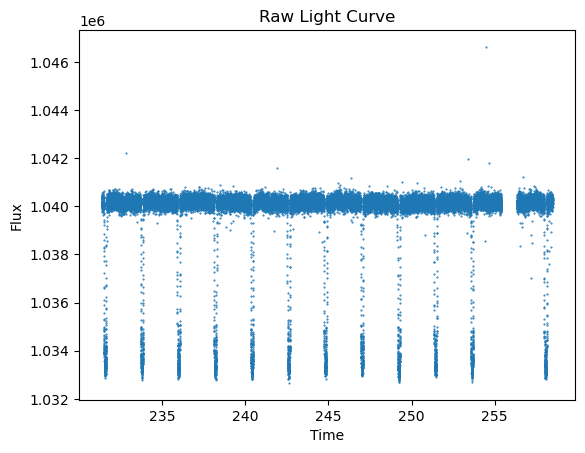

In [4]:
plt.figure()
plt.plot(lc.time.value, lc.flux.value, '.', markersize=1)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Raw Light Curve")
plt.show()

## Period Detection using BLS

We use the Box Least Squares (BLS) algorithm to identify periodic transit signals in the light curve and determine the orbital period of the planet.

In [5]:
time = lc.time.value
flux = lc.flux.value

periods = np.linspace(1, 3, 5000)

model = BoxLeastSquares(time, flux)
result = model.power(periods, 0.1)

best_period = periods[np.argmax(result.power)]
print("Detected Period:", best_period)

Detected Period: 2.204640928185637


## Phase Folding

We fold the light curve using the detected period to align all transit events into a single curve. This reveals a clear transit shape.

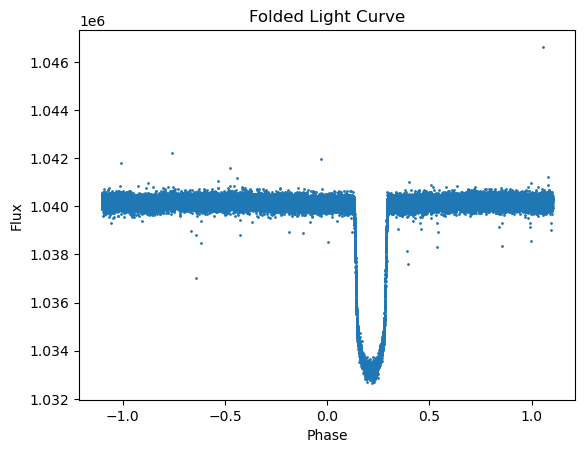

In [6]:
lc_folded = lc.fold(period=best_period)

plt.figure()
plt.scatter(lc_folded.phase.value, lc_folded.flux.value, s=1)
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Folded Light Curve")
plt.show()

## Transit Location

We determine the phase at which the transit occurs by finding the point of minimum brightness in the folded light curve.

In [7]:
min_index = np.argmin(lc_folded.flux.value)
transit_phase = lc_folded.phase.value[min_index]

print("Transit phase:", transit_phase)

Transit phase: 0.21992208389664686


## Transit Depth Estimation

We calculate the transit depth by comparing the normal brightness of the star with the reduced brightness during the transit. This helps estimate the size of the planet relative to the star.

In [8]:
baseline_mask = np.abs(lc_folded.phase.value - transit_phase) > 0.05
transit_mask = np.abs(lc_folded.phase.value - transit_phase) < 0.02

baseline = np.mean(lc_folded.flux.value[baseline_mask])
transit_flux = np.mean(lc_folded.flux.value[transit_mask])

depth = (baseline - transit_flux) / baseline

print("Transit depth:", depth)

Transit depth: 0.006570109


## Final Result

This figure shows the BLS periodogram and the phase-folded light curve.  
The peak in the periodogram indicates the detected orbital period (~2.2 days), while the folded light curve confirms the presence of a transit signal.

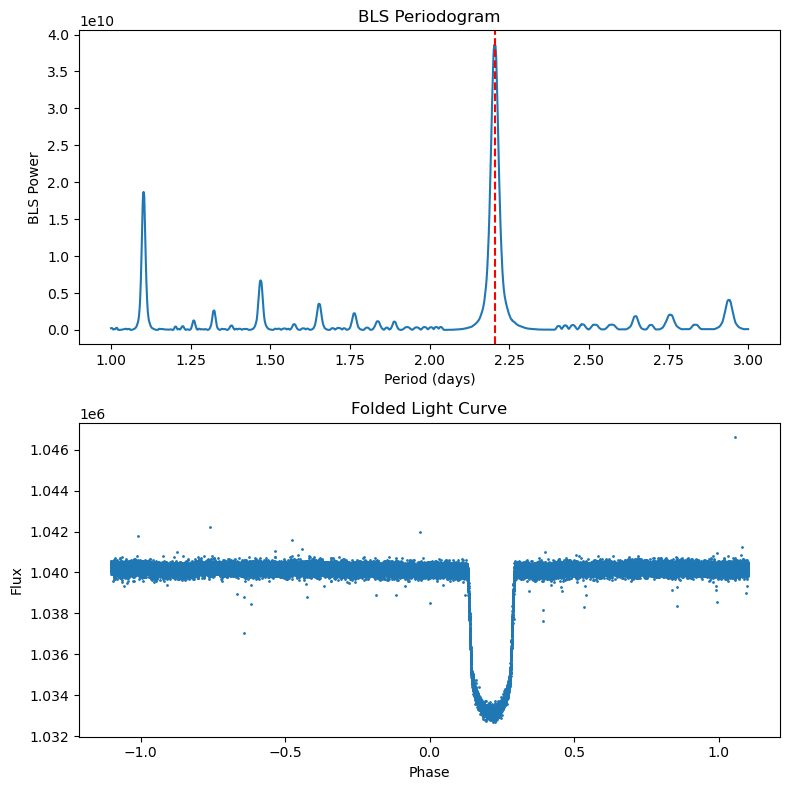

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

# BLS Periodogram
ax[0].plot(periods, result.power)
ax[0].axvline(best_period, color='r', linestyle='--')
ax[0].set_xlabel("Period (days)")
ax[0].set_ylabel("BLS Power")
ax[0].set_title("BLS Periodogram")

# Folded Light Curve
ax[1].scatter(lc_folded.phase.value, lc_folded.flux.value, s=1)
ax[1].set_xlabel("Phase")
ax[1].set_ylabel("Flux")
ax[1].set_title("Folded Light Curve")

plt.tight_layout()
plt.show()

The orbital period is **2.2047 days** and the transit depth is **0.00657**, indicating a hot Jupiter.